# Guia practica: sistema de Lorenz con Runge-Kutta de cuarto orden

Este notebook reproduce la integracion del sistema de Lorenz con un esquema `RK4` para estudiar equilibrio, transicion al caos y sensibilidad a condiciones iniciales.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = Path.cwd().resolve().parents[0]
SUMMARY_PATH = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'resumen_lorenz_rk4.json'
with SUMMARY_PATH.open('r', encoding='utf-8') as f:
    summary = json.load(f)

summary['parameters']

{'sigma': 10.0,
 'beta': 2.6666666666666665,
 'dt': 0.005,
 't_stop': 50.0,
 'initial_condition': [1.0, 1.0, 1.0],
 'perturbed_initial_condition': [1.001, 1.0, 1.0]}

## Sistema y esquema numerico

Se resolvio el sistema

$$\dot{x} = \sigma (y-x), \quad \dot{y} = x(r-z) - y, \quad \dot{z} = xy - bz$$

con `sigma = 10`, `b = 8/3`, `dt = 0.005`, `t in [0, 50]` y condicion inicial `(x0, y0, z0) = (1, 1, 1)`.

## Caso r = 2

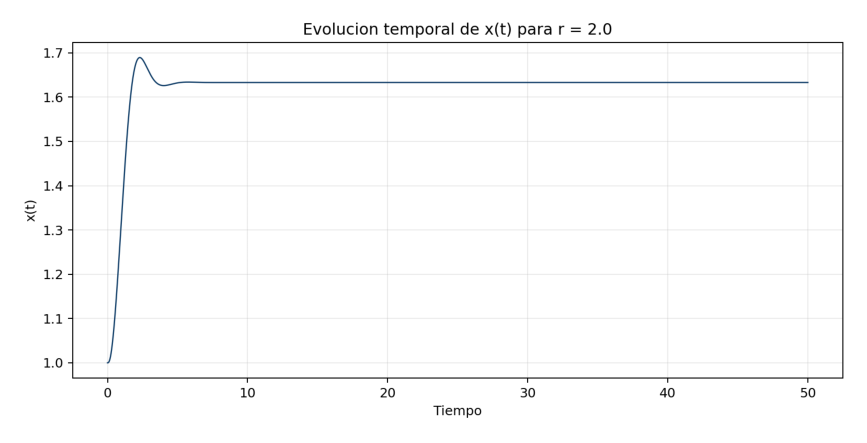

In [2]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r2_xt.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Comparacion r = 10 y r = 24: evolucion temporal

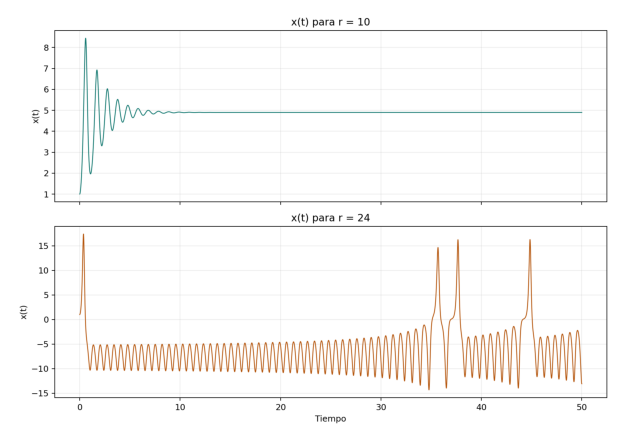

In [3]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r10_r24_xt.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Comparacion r = 10 y r = 24: espacio de fases

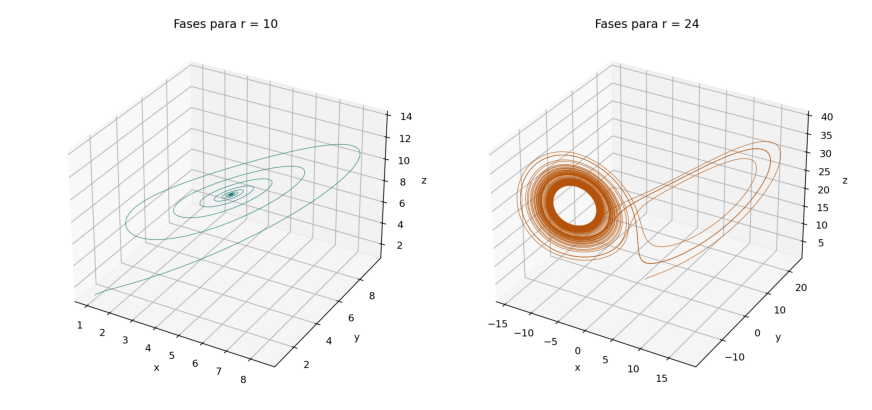

In [4]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r10_r24_fases.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso r = 25

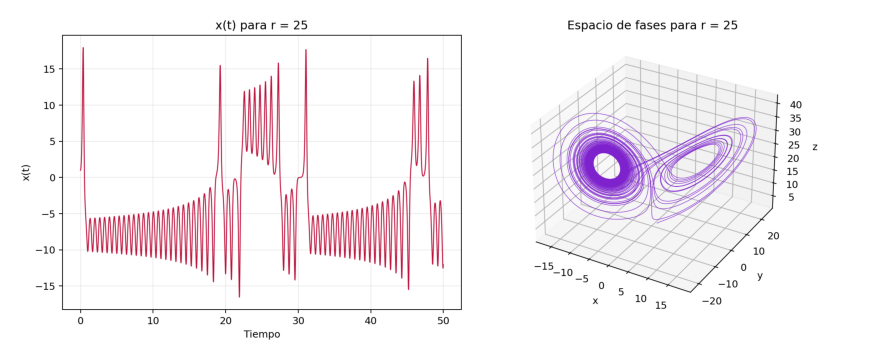

In [5]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r25_xt_fases.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso r = 30: espacio de fases

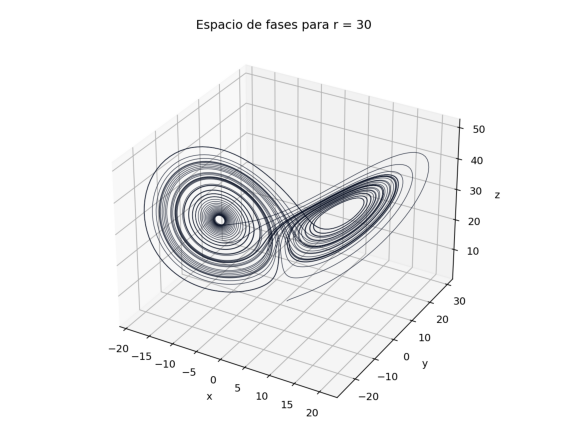

In [6]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r30_fases.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso r = 30: comparacion de trayectorias en fases

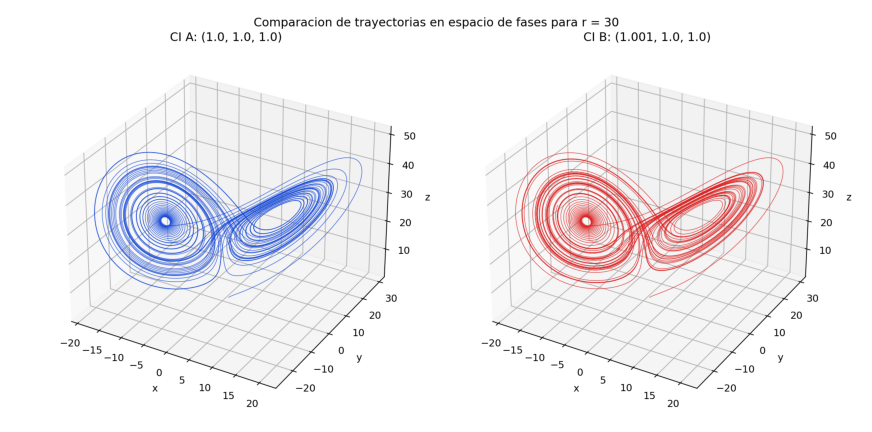

In [7]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r30_fases_comparacion.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso r = 30: sensibilidad a condiciones iniciales

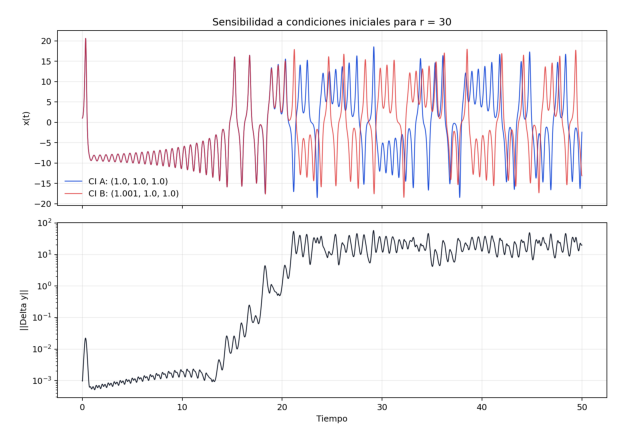

In [8]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r30_sensibilidad.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Resumen numerico

In [9]:
rows = []
for key, values in summary['cases'].items():
    rows.append({
        'r': key,
        'x_std_ultimos_10': round(values['x_std_last_10_time_units'], 4),
        'dist_min_equilibrio_no_trivial': None if values['min_distance_nonzero_fixed_point'] is None else round(values['min_distance_nonzero_fixed_point'], 4),
        'x_min': round(values['x_min'], 4),
        'x_max': round(values['x_max'], 4),
    })
rows

[{'r': '2.0',
  'x_std_ultimos_10': 0.0,
  'dist_min_equilibrio_no_trivial': 0.0,
  'x_min': 1.0,
  'x_max': 1.6893},
 {'r': '10.0',
  'x_std_ultimos_10': 0.0,
  'dist_min_equilibrio_no_trivial': 0.0,
  'x_min': 1.0,
  'x_max': 8.4428},
 {'r': '24.0',
  'x_std_ultimos_10': 4.9588,
  'dist_min_equilibrio_no_trivial': 3.8788,
  'x_min': -14.3432,
  'x_max': 17.3983},
 {'r': '25.0',
  'x_std_ultimos_10': 6.6298,
  'dist_min_equilibrio_no_trivial': 3.4711,
  'x_min': -16.5268,
  'x_max': 17.9504},
 {'r': '30.0',
  'x_std_ultimos_10': 8.295,
  'dist_min_equilibrio_no_trivial': 1.0406,
  'x_min': -18.5138,
  'x_max': 20.6079}]

In [10]:
summary['sensitivity_r30']

{'divergence_time_norm_gt_5': 20.830000000000002,
 'divergence_time_norm_gt_10': 20.91,
 'final_distance': 19.924143985794974}